# Week 1: Breast Cancer Classifier using k-NN Classifier

This is an exercise attempting to recreate the Week 1 example as demonstrated in class. We are using *UCI Breast Cancer Wisconsin (Original)* as found on Kaggle. 

https://www.kaggle.com/datasets/zzero0/uci-breast-cancer-wisconsin-original

In [114]:
import kagglehub
path = kagglehub.dataset_download("zzero0/uci-breast-cancer-wisconsin-original")

### Background

k-NN is a supervised learning model where our goal is to train a model for classification.

Training data is represented:
$$
\mathcal{D} = \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}
$$
$$
x_i \in \mathbb{R}^d \quad \text{(feature vectors)}, \quad
y_i \in \mathcal{Y} \quad \text{(labels)}
$$
where our goal is to predict the label $y$ for a new point $x$.

The set of k nearest neighbours of a point $x$:
$$
\mathcal{N}_k(x) = \arg\min_{S \subset \{1, \dots, n\},\, |S| = k} \sum_{i \in S} d(x, x_i)
$$
with $k$ representing the number of neighbours closest to our point with respect to some distance function $d(x, x_i)$. Common distance functions include euclidean, manhattan, etc.

Euclidean Distance:
$$
\|x_i - x^*\|_2
=
\sqrt{
\sum_{j=1}^{d}
\left(x_{ij} - x_j^*\right)^2
}
$$

Intuitvely, $\mathcal{N}_k(x)$ is the set of indices corresponding to the $k$ points in the dataset that are closest to $x$ according to the distance metric. 

We predict the class for a new point $x$ given:

$$
\hat{y} = \text{mode} \Big( \{ y_i : i \in \mathcal{N}_k(x) \} \Big)
$$

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
%matplotlib inline

import os

warnings.filterwarnings('ignore')

# Load the dataset
data_file = os.path.join(path, "breast-cancer-wisconsin.data.txt")
df = pd.read_csv(data_file)

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (698, 11)
   1000025  5   1  1.1  1.2  2 1.3  3  1.4  1.5  2.1
0  1002945  5   4    4    5  7  10  3    2    1    2
1  1015425  3   1    1    1  2   2  3    1    1    2
2  1016277  6   8    8    1  3   4  3    7    1    2
3  1017023  4   1    1    3  2   1  3    1    1    2
4  1017122  8  10   10    8  7  10  9    7    1    4


In [187]:
col_names = ['Id', 'Clump_thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 
             'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']
df.columns = col_names
df.head()

,Id,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [188]:
df.drop('Id', axis=1, inplace=True)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clump_thickness              698 non-null    int64
 1   Uniformity_Cell_Size         698 non-null    int64
 2   Uniformity_Cell_Shape        698 non-null    int64
 3   Marginal_Adhesion            698 non-null    int64
 4   Single_Epithelial_Cell_Size  698 non-null    int64
 5   Bare_Nuclei                  698 non-null    str  
 6   Bland_Chromatin              698 non-null    int64
 7   Normal_Nucleoli              698 non-null    int64
 8   Mitoses                      698 non-null    int64
 9   Class                        698 non-null    int64
dtypes: int64(9), str(1)
memory usage: 55.5 KB


In [189]:
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'], errors='coerce')
df.dtypes

Clump_thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object

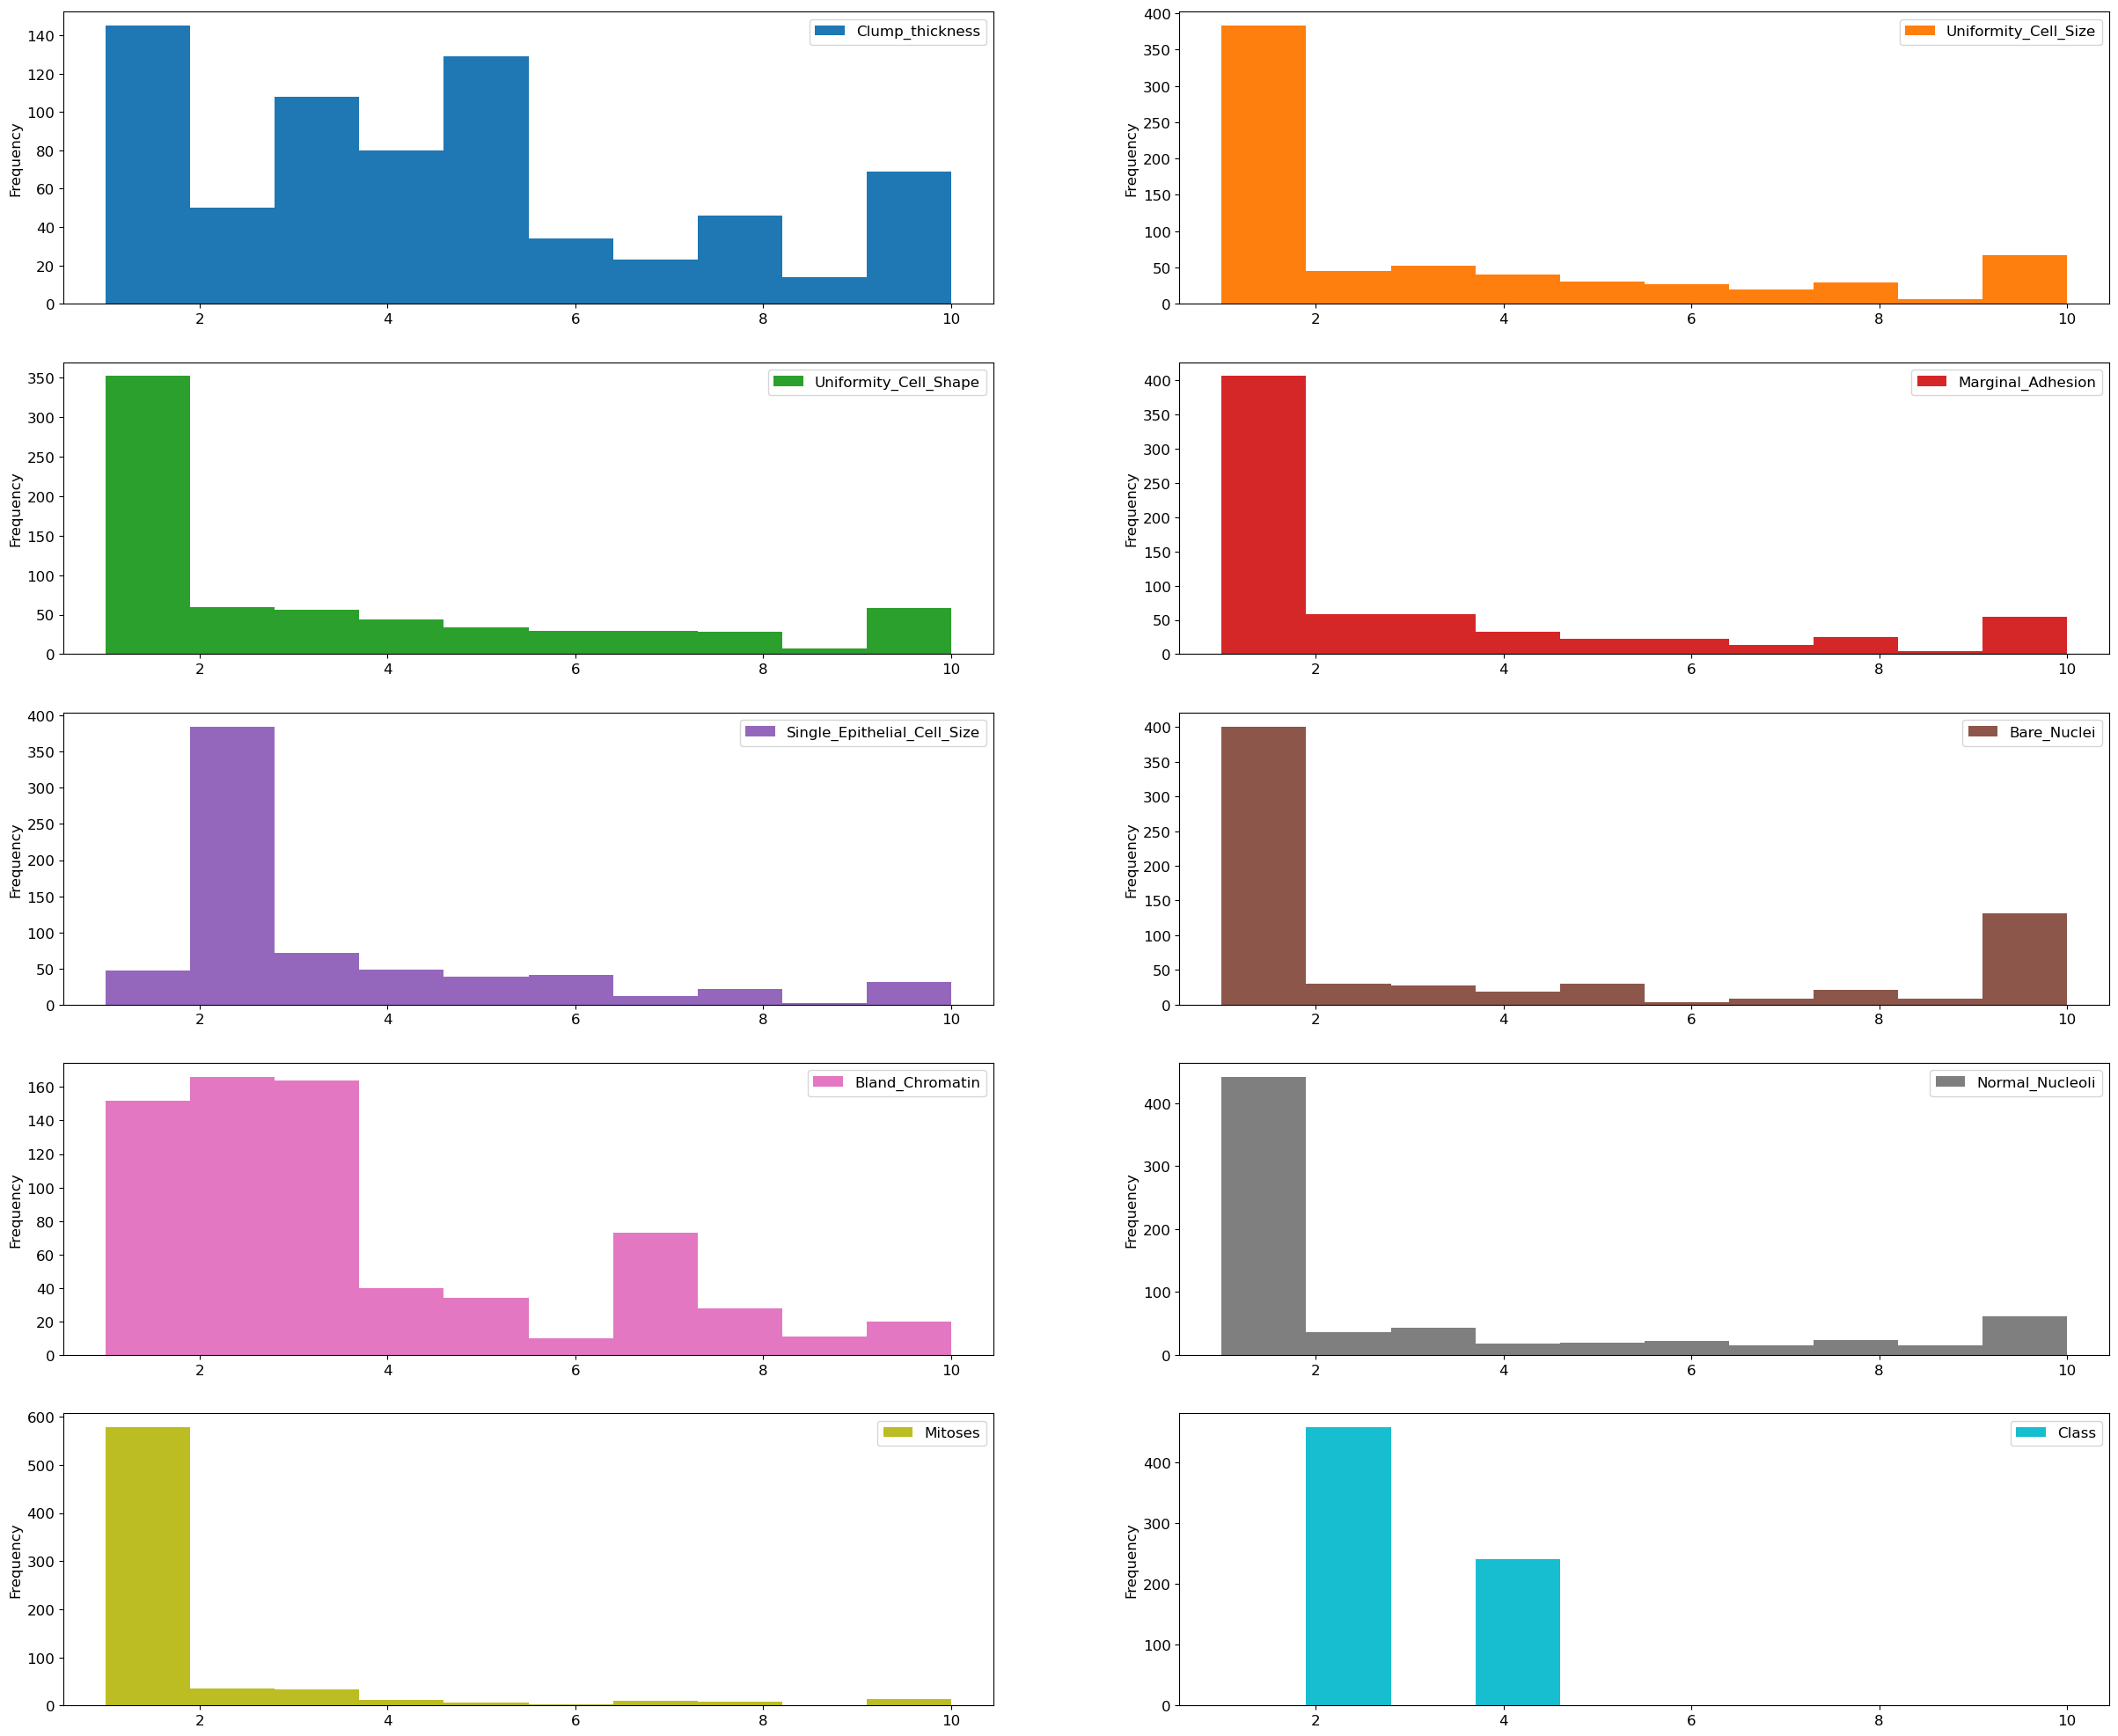

In [190]:
plt.rcParams['figure.figsize']=(30,25)

df.plot(kind='hist', bins=10, subplots=True, layout=(5,2), sharex=False, sharey=False)

plt.show()

In [191]:
corr = df.corr()
corr['Class'].sort_values(ascending=False)

Class                          1.000000
Bare_Nuclei                    0.822563
Uniformity_Cell_Shape          0.818794
Uniformity_Cell_Size           0.817772
Bland_Chromatin                0.756732
Clump_thickness                0.716509
Normal_Nucleoli                0.712067
Marginal_Adhesion              0.696605
Single_Epithelial_Cell_Size    0.682618
Mitoses                        0.423008
Name: Class, dtype: float64

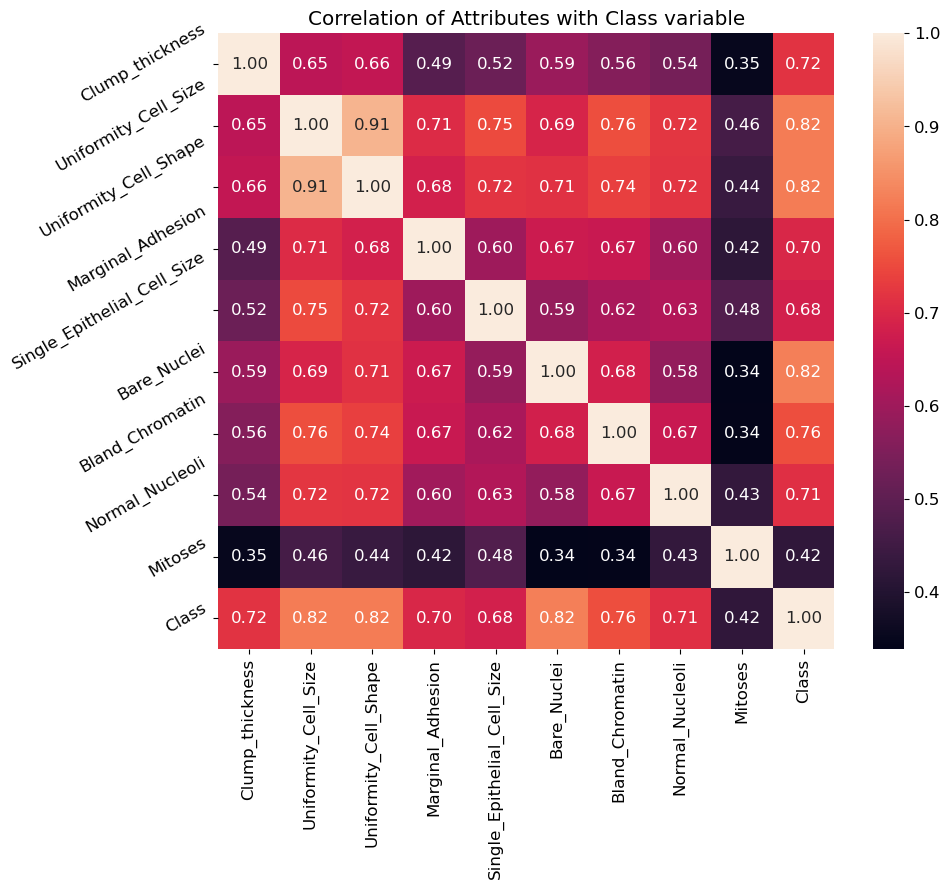

In [192]:
plt.figure(figsize=(10, 8))
plt.title('Correlation of Attributes with Class variable')
a = sns.heatmap(corr, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)           
plt.show()

In [193]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [194]:
X_train.shape, X_test.shape

((558, 9), (140, 9))

In [195]:
X_train.dtypes

Clump_thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
dtype: object

In [196]:
# check missing values
X_train.isnull().sum()

Clump_thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    13
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
dtype: int64

In [197]:
X_test.isnull().sum()

Clump_thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    3
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
dtype: int64

In [198]:
# print percentage of missing values in the numerical variables in training set

for col in X_train.columns:
    if X_train[col].isnull().mean()>0:
        print(col, round(X_train[col].isnull().mean(),4))

Bare_Nuclei 0.0233


In [199]:
for df1 in [X_train, X_test]:
    for col in X_train.columns:
        col_median = X_train[col].median()
        df1[col] = df1[col].fillna(col_median)

In [200]:
X_train.isnull().sum()

Clump_thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
dtype: int64

In [201]:
X_train.head()

,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
82,3,1,1,1,2,2.0,7,1,1
51,10,3,6,2,3,5.0,4,10,2
220,10,6,4,3,10,10.0,9,10,1
559,5,1,1,1,2,1.0,3,1,1
544,5,1,1,1,2,1.0,2,1,1


In [202]:
X_test.head()

,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
158,9,9,10,3,6,10.0,7,10,6
499,6,1,1,1,2,1.0,3,1,1
396,4,1,1,1,2,1.0,1,1,1
155,1,2,2,1,2,1.0,2,1,1
321,3,1,1,1,2,1.0,3,1,1


In [203]:
cols = X_train.columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [204]:
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])
X_train.head()

,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,-0.499014,-0.686318,-0.741845,-0.627477,-0.533140,-0.402916,1.494165,-0.600954,-0.322901
1,1.968261,-0.019131,0.965868,-0.270564,-0.074047,0.434949,0.255931,2.447523,0.258320
2,1.968261,0.981650,0.282783,0.086350,3.139602,1.831391,2.319654,2.447523,-0.322901
3,0.205922,-0.686318,-0.741845,-0.627477,-0.533140,-0.682204,-0.156813,-0.600954,-0.322901
4,0.205922,-0.686318,-0.741845,-0.627477,-0.533140,-0.682204,-0.569558,-0.600954,-0.322901


In [205]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [206]:
y_pred = knn.predict(X_test)

In [207]:
from sklearn.metrics import accuracy_score
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.9786


In [208]:
y_pred_train = knn.predict(X_train)
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.9767


In [209]:
print('Training set score: {:.4f}'.format(knn.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(knn.score(X_test, y_test)))

Training set score: 0.9767
Test set score: 0.9786


In [210]:
y_test.value_counts()

Class
2    89
4    51
Name: count, dtype: int64

In [211]:
null_accuracy = (85/(85+55))
print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

Null accuracy score: 0.6071


In [212]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use best model to make predictions
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
test_accuracy = (y_pred == y_test).mean()
print(f"Test set accuracy: {test_accuracy:.4f}")

Best parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Best cross-validation score: 0.9660
Test set accuracy: 0.9786


In [213]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', cm)
print('\nTrue Positives(TP) = ', cm[0,0])
print('\nTrue Negatives(TN) = ', cm[1,1])
print('\nFalse Positives(FP) = ', cm[0,1])
print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[86  3]
 [ 0 51]]

True Positives(TP) =  86

True Negatives(TN) =  51

False Positives(FP) =  3

False Negatives(FN) =  0


<Axes: >

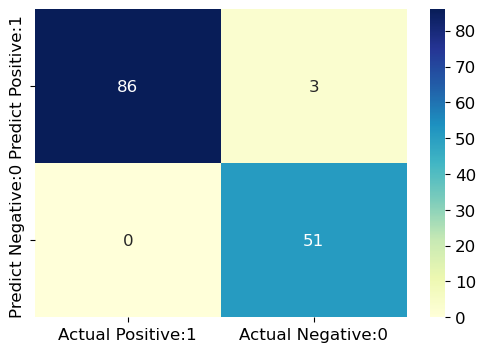

In [214]:
plt.figure(figsize=(6,4))

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [215]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       1.00      0.97      0.98        89
           4       0.94      1.00      0.97        51

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



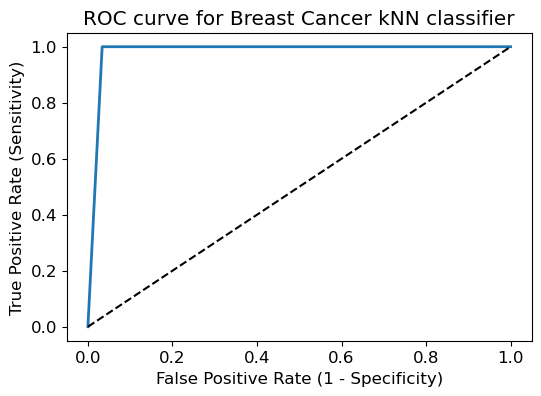

In [216]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=4)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], 'k--' )
plt.rcParams['font.size'] = 12
plt.title('ROC curve for Breast Cancer kNN classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.show()

In [217]:
from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_test, y_pred)
print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.9831


In [218]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn, X_train, y_train, cv = 10, scoring='accuracy')
print('Cross-validation scores:{}'.format(scores))

Cross-validation scores:[0.98214286 0.96428571 0.96428571 0.96428571 0.98214286 0.94642857
 0.96428571 0.94642857 0.94545455 0.98181818]


In [219]:
print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Average cross-validation score: 0.9642
